In [1]:
from matplotlib.ticker import MaxNLocator
from logit import *
from scipy.stats import pearsonr as rho
import matplotlib

def get_corr(x1,x2,N=10000):
    r=(rho(x1,x2)[0])
    r_resample = []
    for i in np.arange(N):
        r_resample.append(rho(np.random.choice(x1, size=len(x1), replace=True), np.random.choice(x2, size=len(x2), replace=True))[0])
    return r, (r_resample >= r).sum() / N


In [3]:
#Load daily dataframe with model and obs data
_, era5_aws, era5_sta = optimise_pss("/g/data/eg3/ab4502/ExtremeWind/points/"+
            "era5_allvars_v3_2005_2018.pkl", T=1000, compute=False, l_thresh=2,
            is_pss="hss", model_name="era5_v5", time="floor") 
era5_aws["year"] = pd.DatetimeIndex(era5_aws["hourly_floor_utc"]).year
era5_aws["month"] = pd.DatetimeIndex(era5_aws["hourly_floor_utc"]).month

#Fit statistical regression models to measured and reported (STA events)
era5_aws_preds = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl"] 
era5_sta_preds = ["ebwd","Umean06","ml_cape","lr13"]
logit = LogisticRegression(class_weight="balanced", solver="liblinear",
                 max_iter=1000) 
era5_aws.loc[:,"logit"] = logit.fit(era5_aws[era5_aws_preds], era5_aws["is_conv_aws"]).predict_proba(era5_aws[era5_aws_preds])[:,1] 
era5_aws.loc[:,"logit_sta"] = logit.fit(era5_sta[era5_sta_preds], era5_sta["is_sta"]).predict_proba(era5_aws[era5_sta_preds])[:,1] 

#Get the yearly and monthly time series
v="logit"
thresh=0.83
y1=[]; y2=[]
for y in np.arange(2005,2019): 
         y1.append((era5_aws[(era5_aws.year==y)][v]>=thresh).sum()) 
         y2.append(era5_aws[(era5_aws.year==y)]["is_conv_aws"].sum()) 
m1=[]; m2=[] 
for m in np.arange(1,13): 
         m1.append((era5_aws[(era5_aws.month==m)][v] >= thresh).sum()) 
         m2.append(era5_aws[(era5_aws.month==m)]["is_conv_aws"].sum()) 

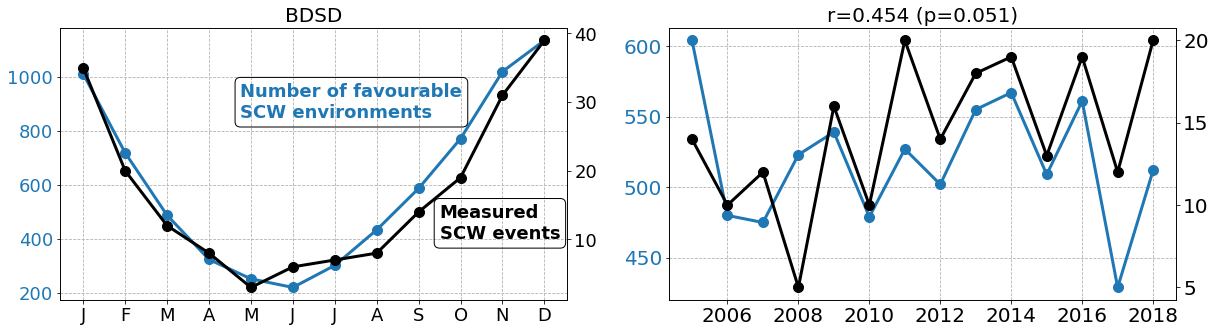

In [59]:
plt.figure(figsize=[20,5])

c1="tab:blue"
c2="k"

ax1=plt.subplot(1,2,1)
ax1.plot(np.arange(1,13), m1, color=c1, marker="o",lw=3,ms=10)
ax1.grid(axis="both",ls="--")
ax1.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"],fontdict={"fontsize":18})
ax1.tick_params(axis="y",labelcolor=c1,labelsize=18)
ax1.text(4.75,850,"Number of favourable\nSCW environments",size=18,weight=575,color=c1,bbox=dict(edgecolor='k', alpha=1, fill=False, boxstyle="round"))
ax1.text(9.5,400,"Measured\nSCW events",size=18,color=c2,weight=575,bbox=dict(edgecolor='k', alpha=1, fill=False, boxstyle="round"))

ax2=plt.gca().twinx()
ax2.plot(np.arange(1,13), m2, color=c2,marker="o",lw=3,ms=10)

plt.title("BDSD",size=20)
ax2.set_xticks(np.arange(1,13,1))
ax2.tick_params(axis="both",labelsize=18)

ax1=plt.subplot(1,2,2)
r, p = get_corr(y1,y2)
plt.title(("r={:.3f} (p={:.3f})").format(r,p),size=20)
ax1.plot(np.arange(2005,2019), y1, label=v, color=c1,marker="o",lw=3,ms=10)
ax1.grid(axis="both",ls="--")
ax1.tick_params(axis="y",labelcolor=c1,labelsize=20)
ax1.tick_params(axis="x",labelsize=20)
ax2=plt.gca().twinx()
ax2.plot(np.arange(2005,2019), y2, color=c2, label="SCW events",marker="o",lw=3,ms=10)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.tick_params(axis="y",labelsize=20)

plt.savefig("/g/data/eg3/ab4502/figs/ExtremeWind/bdsd_variability.jpeg",dpi=300,bbox_inches="tight")
